In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [26]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceEUR,hour,day_of_week,month,year,is_weekend,price_lag_24h,...,offshore_wind_mwh,onshore_wind_mwh,solar_mwh,total_wind_mwh,renewable_generation_mwh,net_load_mwh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeGreatBelt_MWh,PowerToHeatMWh
0,2024-01-07 23:00:00,2024-01-08 00:00:00,DK2,87.019997,0,0,1,2024,0,86.150002,...,791.7307,300.389069,0.057306,1092.119769,1092.177075,791.314215,528.98475,73.031,-494.5,69.490823
1,2024-01-08 00:00:00,2024-01-08 01:00:00,DK2,84.320000,1,0,1,2024,0,82.459999,...,816.1792,326.746273,0.063193,1142.925473,1142.988666,727.853534,352.17200,201.702,-504.2,63.681755
2,2024-01-08 01:00:00,2024-01-08 02:00:00,DK2,81.820000,2,0,1,2024,0,79.220001,...,811.9769,313.381953,0.052199,1125.358853,1125.411052,707.195154,183.17925,419.060,-570.6,62.729644
3,2024-01-08 02:00:00,2024-01-08 03:00:00,DK2,79.110001,3,0,1,2024,0,77.529999,...,802.1109,273.226503,0.054638,1075.337403,1075.392041,738.309639,-18.11300,300.730,-221.5,61.851473
4,2024-01-08 03:00:00,2024-01-08 04:00:00,DK2,78.480003,4,0,1,2024,0,76.889999,...,789.7893,262.512406,0.060724,1052.301706,1052.362430,742.929387,-313.90875,438.479,-57.0,64.752116


In [27]:
print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())
print("Missing values:", df.isna().sum())
print("Duplicated HourUTC:", df["HourUTC"].duplicated().sum())

Rows: 9815
Date range: 2024-01-07 23:00:00 → 2025-02-19 21:00:00
Missing values: HourUTC                     0
HourDK                      0
PriceArea                   0
SpotPriceEUR                0
hour                        0
day_of_week                 0
month                       0
year                        0
is_weekend                  0
price_lag_24h               0
price_lag_48h               0
price_lag_168h              0
price_rolling_mean_24h      0
price_rolling_std_24h       0
price_rolling_mean_168h     0
price_rolling_std_168h      0
target_next_hour            0
temperature_2m              0
wind_speed_10m              0
wind_speed_100m             0
cloud_cover                 0
shortwave_radiation         0
GrossConsumptionMWh         0
CentralPowerMWh             0
LocalPowerMWh               0
CommercialPowerMWh          0
offshore_wind_mwh           0
onshore_wind_mwh            0
solar_mwh                   0
total_wind_mwh              0
renewable_generatio

In [28]:
split_date = "2024-11-01"

train = df[df["HourUTC"] < split_date].copy()
test = df[df["HourUTC"] >= split_date].copy()

print("Train rows:", len(train))
print("Test rows:", len(test))

print("Train range:", train["HourUTC"].min(), "→", train["HourUTC"].max())
print("Test range:", test["HourUTC"].min(), "→", test["HourUTC"].max())

Train rows: 7153
Test rows: 2662
Train range: 2024-01-07 23:00:00 → 2024-10-31 23:00:00
Test range: 2024-11-01 00:00:00 → 2025-02-19 21:00:00


In [29]:
test["pred_current_price"] = test["SpotPriceEUR"]
test["pred_lag_24h"] = test["price_lag_24h"]
test["pred_lag_168h"] = test["price_lag_168h"]
test["pred_rolling_mean_24h"] = test["price_rolling_mean_24h"]
test["pred_rolling_mean_168h"] = test["price_rolling_mean_168h"]

In [30]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    }

In [31]:
results = []

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_current_price"],
    "Current price baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_lag_24h"],
    "Lag 24h baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_lag_168h"],
    "Lag 168h baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_rolling_mean_24h"],
    "Rolling mean 24h baseline"
))

results.append(evaluate_forecast(
    test["target_next_hour"],
    test["pred_rolling_mean_168h"],
    "Rolling mean 168h baseline"
))

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE
0,Current price baseline,12.31,24.48
1,Lag 24h baseline,45.13,69.95
2,Lag 168h baseline,60.77,94.13
3,Rolling mean 24h baseline,35.92,56.36
4,Rolling mean 168h baseline,49.39,73.12


In [32]:
results_df = results_df.sort_values("MAE").reset_index(drop=True)
results_df

,model,MAE,RMSE
0,Current price baseline,12.31,24.48
1,Rolling mean 24h baseline,35.92,56.36
2,Lag 24h baseline,45.13,69.95
3,Rolling mean 168h baseline,49.39,73.12
4,Lag 168h baseline,60.77,94.13


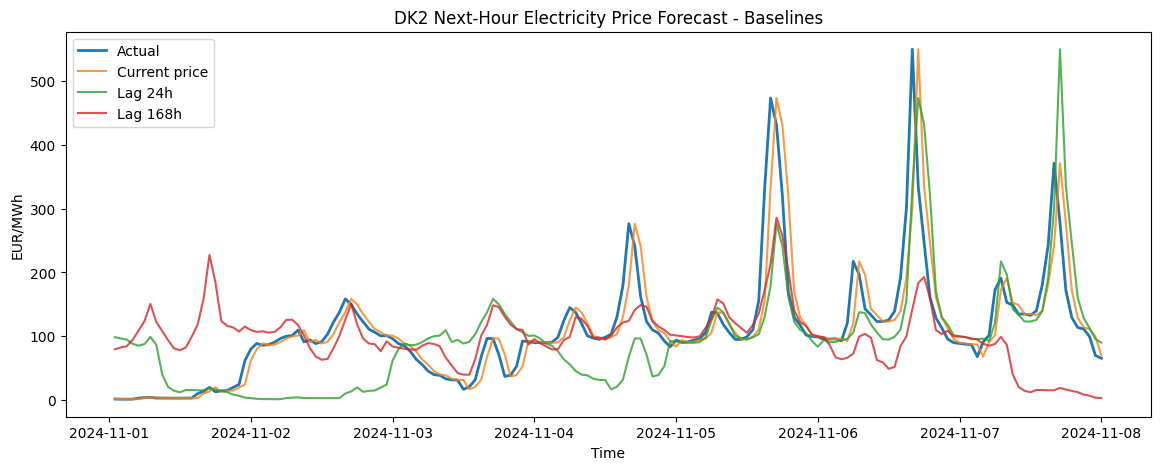

In [33]:
sample = test.head(168)

plt.figure(figsize=(14, 5))

plt.plot(
    sample["HourDK"],
    sample["target_next_hour"],
    label="Actual",
    linewidth=2
)

plt.plot(
    sample["HourDK"],
    sample["pred_current_price"],
    label="Current price",
    alpha=0.8
)

plt.plot(
    sample["HourDK"],
    sample["pred_lag_24h"],
    label="Lag 24h",
    alpha=0.8
)

plt.plot(
    sample["HourDK"],
    sample["pred_lag_168h"],
    label="Lag 168h",
    alpha=0.8
)

plt.title("DK2 Next-Hour Electricity Price Forecast - Baselines")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

In [34]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv("../reports/baseline_results_DK2.csv", index=False)